In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/sample_data/amazon.csv')


In [5]:
len(df)

1465

In [6]:
df.describe()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B083342NKJ,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [8]:

df['actual_price'] = df['actual_price'].str.replace(',',"")
df['actual_price'] = df['actual_price'].str.replace('₹',"")
df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce')

df['discounted_price'] = df['discounted_price'].str.replace(',',"")
df['discounted_price'] = df['discounted_price'].str.replace('₹',"")
df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce')

df['rating_count'] = df['rating_count'].str.replace(',','')
df['rating_count'] = pd.to_numeric(df['rating_count'],errors='coerce')
df['rating_count'] = df['rating_count'].fillna(0)


In [9]:
df['discount_percentage'] =df['discount_percentage'].str.replace('%',"")


In [30]:
df['discount_percentage'] =pd.to_numeric(df['discount_percentage'],errors= 'coerce')/100
df['rating'] = pd.to_numeric(df['rating'],errors='coerce')

In [11]:
df.head(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,0.64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,0.43,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,0.90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,0.53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,0.61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [12]:
df['main_category'] = df['category'].str.split('|').str[0]
df['sub_category1'] = df['category'].str.split('|').str[1]
df['sub_category2'] = df['category'].str.split('|').str[2]
df[['main_category',"sub_category1","sub_category2"] ]

,main_category,sub_category1,sub_category2
0,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
1,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
2,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
3,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
4,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
...,...,...,...
1460,Home&Kitchen,Kitchen&HomeAppliances,WaterPurifiers&Accessories
1461,Home&Kitchen,Kitchen&HomeAppliances,SmallKitchenAppliances
1462,Home&Kitchen,"Heating,Cooling&AirQuality",RoomHeaters
1463,Home&Kitchen,"Heating,Cooling&AirQuality",Fans


In [26]:
df = df.dropna(subset=['sub_category2'])

In [32]:
#check cleaning step

print(df.isnull().sum())
df.info()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
main_category          0
sub_category1          0
sub_category2          0
savings                0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 1457 entries, 0 to 1464
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1457 non-null   object 
 1   product_name         1457 non-null   object 
 2   category             1457 non-null   object 
 3   discounted_price     1457 non-null   float64
 4   actual_price         1457 non-null   float64
 5   discount_percentage  1457 non-

In [84]:
#feature engineering
df['savings']  = df['actual_price']-df['discounted_price']
df['performance_score'] = df['rating'] * df['rating_count']
df['short_name'] = df['product_name'].str.slice(0, 37) + '...'

In [81]:
top_reviewed['short_name']

,short_name
65,"Amazon Basics High-Speed HDMI Cable, ..."
47,"Amazon Basics High-Speed HDMI Cable, ..."
12,AmazonBasics Flexible Premium HDMI Ca...
684,AmazonBasics Flexible Premium HDMI Ca...
400,boAt Bassheads 100 in Ear Wired Earph...
352,boAt Bassheads 100 in Ear Wired Earph...
584,boAt BassHeads 100 in-Ear Wired Headp...
371,"Redmi 9A Sport (Coral Green, 2GB RAM,..."
370,"Redmi 9 Activ (Carbon Black, 4GB RAM,..."
473,"Redmi 9A Sport (Carbon Black, 2GB RAM..."


In [38]:
total_products = df['product_id'].nunique()
total_categories = df['main_category'].nunique()
avg_actual_price = round(df['actual_price'].mean(),2)
avg_discounted_price = round(df['discounted_price'].mean(),2)
avg_discount = df['discount_percentage'].mean()
avg_rating = round(df['rating'].mean(),2)
avg_rating_count = round(df['rating_count'].mean(),2)

print("Total products:", total_products)
print("Total categories:", total_categories)
print("Average actual price:", avg_actual_price)
print("Average discounted price:", avg_discounted_price)
print("Average discount:", avg_discount)
print("Average rating:", avg_rating)
print("Average rating count:", avg_rating_count)

Total products: 1343
Total categories: 9
Average actual price: 5422.38
Average discounted price: 3110.52
Average discount: 0.004775428963623885
Average rating: 4.1
Average rating count: 18321.03


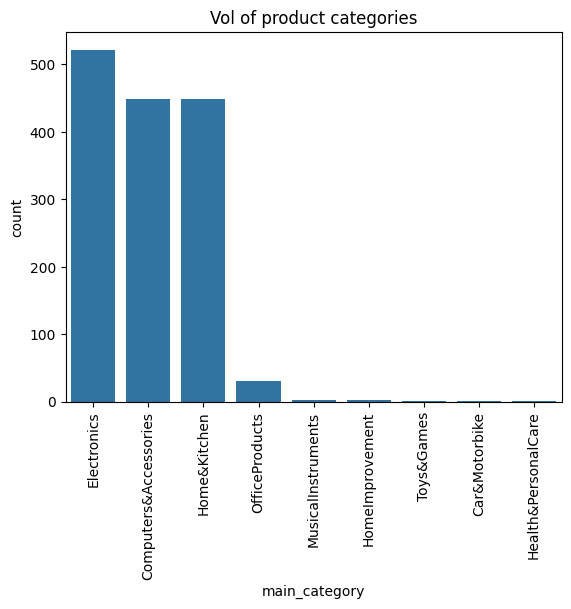

In [59]:
count_vals = df['main_category'].value_counts().index
sns.countplot(data=df, x='main_category', order =count_vals)
plt.title('Vol of product categories')
plt.xticks(rotation =90)
plt.show()

Text(0.5, 1.0, 'Distribution all products ratings')

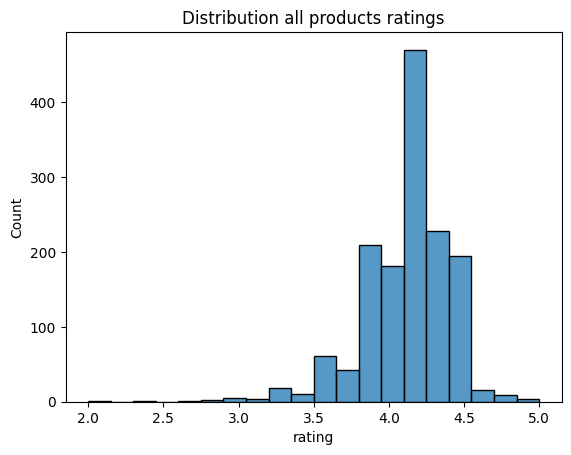

In [57]:
#Distribution of ratings accross all products

sns.histplot(data=df, x ='rating',bins =20)
plt.title('Distribution all products ratings')

Text(0.5, 1.0, 'Distribution of dicount prices')

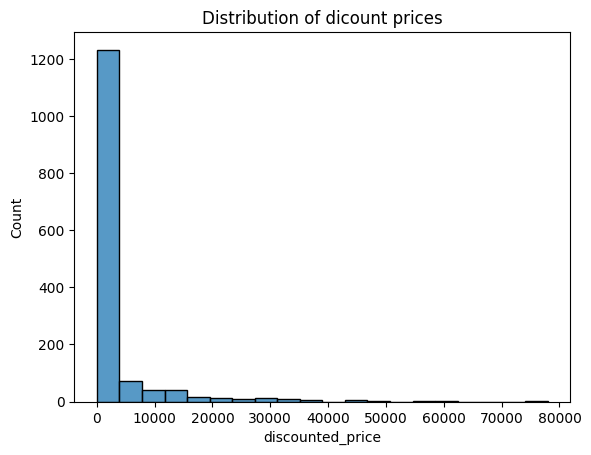

In [86]:
#Distribution of discounted_price accross all products

sns.histplot(data=df, x ='discounted_price',bins =20)
plt.title('Distribution of dicount prices')

In [60]:
df['main_category'].value_counts().index

Index(['Electronics', 'Computers&Accessories', 'Home&Kitchen',
       'OfficeProducts', 'MusicalInstruments', 'HomeImprovement', 'Toys&Games',
       'Car&Motorbike', 'Health&PersonalCare'],
      dtype='object', name='main_category')

<Axes: xlabel='discounted_price', ylabel='Count'>

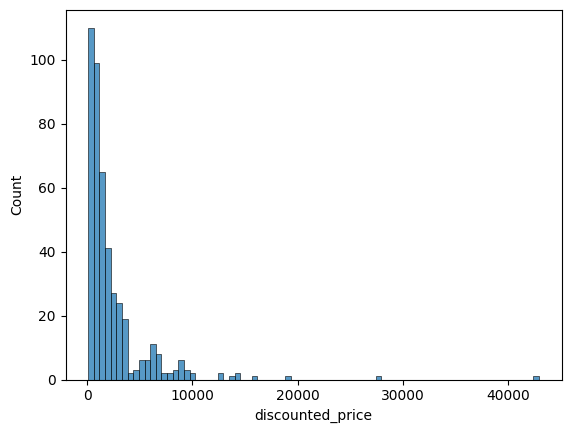

In [63]:
#Distribution of Home&Kitchen dicount prices,
cat_home = df[df['main_category']=='Home&Kitchen']['discounted_price']
sns.histplot(data = df , x= cat_home)

Text(0.5, 1.0, 'Top 10 Most Reviewed Products')

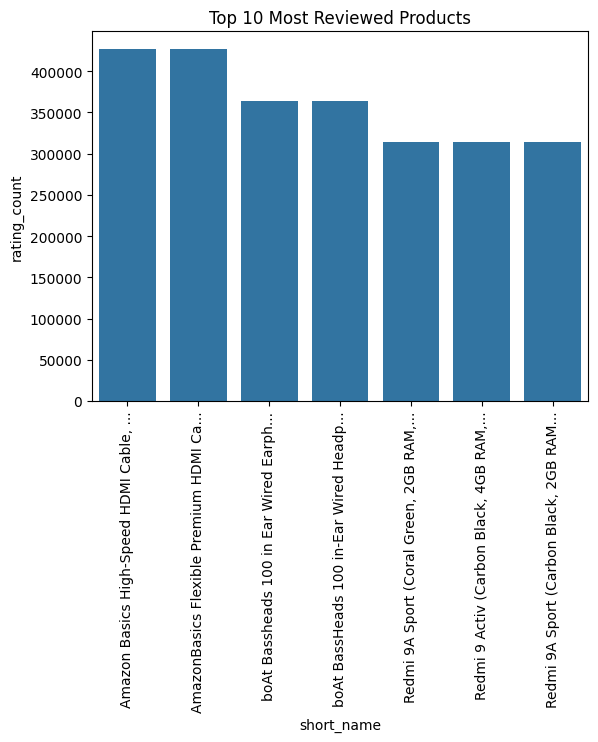

In [85]:
#Top10 products by number of ratings
top_reviewed  = df[['short_name','rating_count']].sort_values(by='rating_count',ascending = False).head(10)
sns.barplot(data = top_reviewed, x ="short_name", y='rating_count' )
plt.xticks(rotation =90)
plt.title('Top 10 Most Reviewed Products')

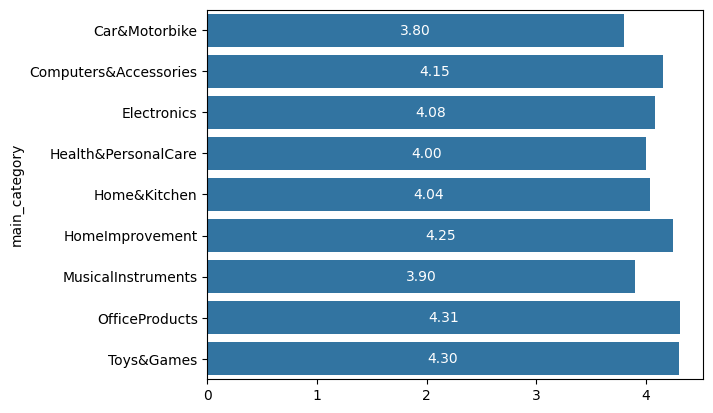

In [104]:
avg_rating_category = df.groupby('main_category')['rating'].mean()
sns.barplot(x = avg_rating_category.values,y=avg_rating_category.index)
for i, value in enumerate(avg_rating_category.values):
    plt.text(value / 2, i, f'{value:.2f}', ha='center', va='center', color='white')
plt.show()